Разработать детектор аномалий на базе сверточного автокодировщика. Необходимо построить сверточный автокодировщик и обучить его используя базу рукописных цифр mnist. В качестве аномалий использовать изображения из базы fashion_mnist. При подаче изображения из базы fashion_mnist на вход нейронной сети алгоритм должен выдавать сообщение: "Изображение не содержит рукописной цифры".

Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Загрузка данных...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Размеры данных:
Обучающая выборка MNIST: (60000, 28, 28, 1)
Тестовая выборка MNIST: (10000, 28, 28, 1)
Тестовая выборка Fashion-MNIST: (10000, 28, 28, 1)

Создание модели...


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 14, 14, 32)     │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 28, 28, 1)      │         4,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,569 (37.38 KB)

 Trainable params: 9,569 (37.38 KB)

 Non-trainable params: 0 (0.00 B)


Начало обучения...
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.1071 - val_loss: 0.0018
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0014 - val_loss: 7.7964e-04
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.1474e-04 - val_loss: 5.6420e-04
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5.3716e-04 - val_loss: 4.6475e-04
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.5109e-04 - val_loss: 4.0808e-04
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.9906e-04 - val_loss: 3.6844e-04
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.6215e-04 - val_loss: 3.3856e-04
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.3411e-04 - val_loss: 3.1565e-04
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.1286e-04 - val_loss: 2.9702e-04
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.9501e-04 - val_loss: 2.8052e-04
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/st

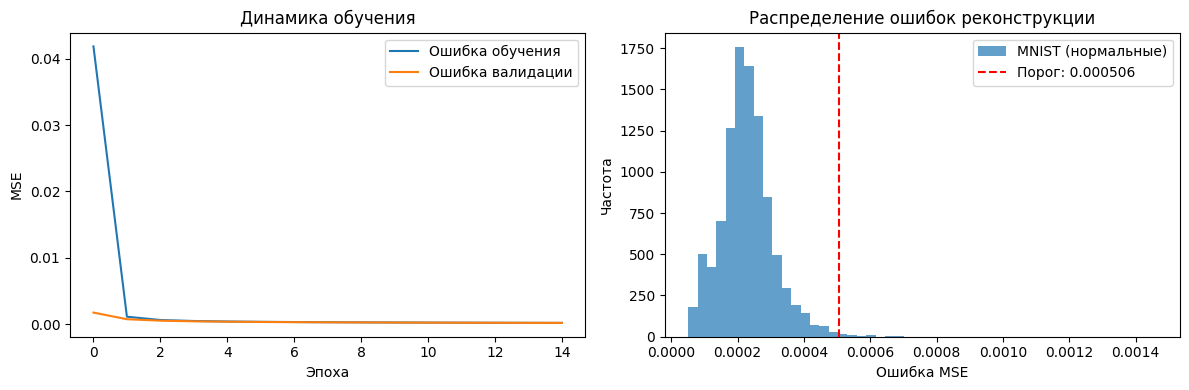


Оценка на аномальных данных (Fashion-MNIST)...

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ
Порог аномалии: 0.000506

Матрица ошибок:
TN (правильные нормальные): 9950
FP (ложные срабатывания): 50
TP (правильные аномалии): 9973
FN (пропущенные аномалии): 27

Метрики качества:
Precision (точность): 0.995
Recall (полнота): 0.997
F1-мера: 0.996
Accuracy (accuracy): 0.996

ДЕМОНСТРАЦИЯ РАБОТЫ ДЕТЕКТОРА

1. Тестирование на изображении из MNIST (нормальные данные):
Введите индекс от 0 до 9999 для выбора изображения из MNIST:
6


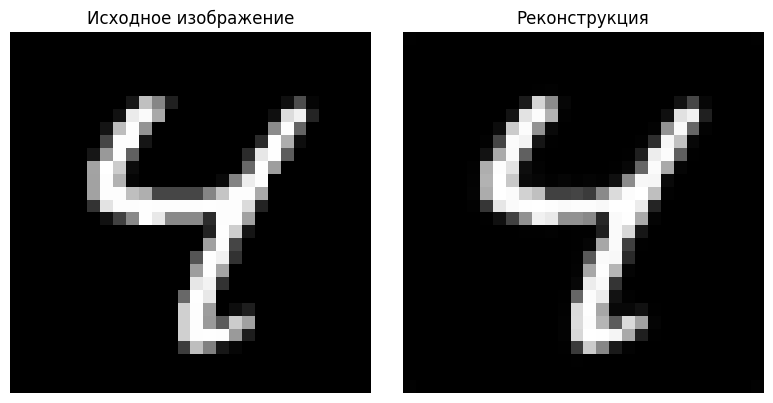

🟢 Изображение содержит рукописную цифру
   Ошибка реконструкции: 0.000199 < 0.000506

2. Тестирование на изображении из Fashion-MNIST (аномалии):
Введите индекс от 0 до 9999 для выбора изображения из Fashion-MNIST:
9


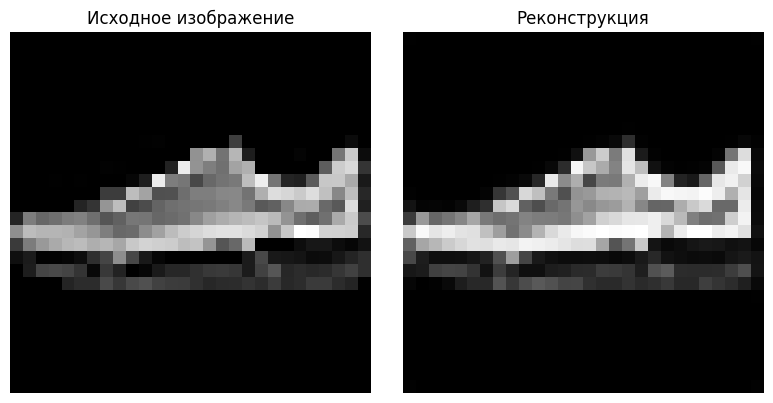

🔴 Изображение не содержит рукописной цифры
   Ошибка реконструкции: 0.002447 > 0.000506


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Проверка доступности GPU
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))

# Установка seed для воспроизводимости
tf.random.set_seed(42)
np.random.seed(42)

# Загрузка данных
print("Загрузка данных...")
(x_train, _), (x_test_mnist, _) = keras.datasets.mnist.load_data()
(_, _), (x_test_fashion, _) = keras.datasets.fashion_mnist.load_data()

# Предобработка данных
def prep(x):
    x = x.astype("float32") / 255.0
    return np.expand_dims(x, -1)

x_train = prep(x_train)
x_test_mnist = prep(x_test_mnist)
x_test_fashion = prep(x_test_fashion)

print(f"Размеры данных:")
print(f"Обучающая выборка MNIST: {x_train.shape}")
print(f"Тестовая выборка MNIST: {x_test_mnist.shape}")
print(f"Тестовая выборка Fashion-MNIST: {x_test_fashion.shape}")

# Создание датасетов
batch_size = 256
train_ds = tf.data.Dataset.from_tensor_slices((x_train, x_train)).shuffle(10000).batch(batch_size).prefetch(2)
val_ds = tf.data.Dataset.from_tensor_slices((x_test_mnist, x_test_mnist)).batch(batch_size)

# Определение модели сверточного автокодировщика
class ConvAutoencoder(keras.Model):
    def __init__(self, latent_filters=32):
        super().__init__()
        # Encoder: 28x28 -> 14x14
        self.enc = keras.Sequential([
            layers.Input(shape=(28,28,1)),
            layers.Conv2D(16, 3, padding="same", activation="relu"),
            layers.Conv2D(latent_filters, 3, strides=2, padding="same", activation="relu"),  # 14x14
        ], name="encoder")

        # Decoder: 14x14 -> 28x28
        self.dec = keras.Sequential([
            layers.Input(shape=(14,14,latent_filters)),
            layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu"),
            layers.Conv2D(1, 3, padding="same", activation="sigmoid"),
        ], name="decoder")

    def call(self, x, training=False):
        z = self.enc(x, training=training)
        return self.dec(z, training=training)

# Создание и компиляция модели
print("\nСоздание модели...")
autoencoder = ConvAutoencoder(latent_filters=32)
autoencoder.compile(optimizer=keras.optimizers.Adam(8e-4), loss="mse")
autoencoder.build((None,28,28,1))
autoencoder.summary()

# Обучение модели
print("\nНачало обучения...")
history = autoencoder.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    verbose=1
)

# Построение графиков обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Ошибка обучения')
plt.plot(history.history['val_loss'], label='Ошибка валидации')
plt.title('Динамика обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()

# Поиск порога по ошибке реконструкции
print("\nОпределение порога аномалии...")
recon_mnist = autoencoder.predict(x_test_mnist, batch_size=512, verbose=0)
err_mnist = np.mean((x_test_mnist - recon_mnist)**2, axis=(1,2,3))

threshold = np.percentile(err_mnist, 99.5)
print(f"Порог аномалии: {threshold:.6f}")

# Визуализация распределения ошибок
plt.subplot(1, 2, 2)
plt.hist(err_mnist, bins=50, alpha=0.7, label='MNIST (нормальные)')
plt.axvline(threshold, color='red', linestyle='--', label=f'Порог: {threshold:.6f}')
plt.title('Распределение ошибок реконструкции')
plt.xlabel('Ошибка MSE')
plt.ylabel('Частота')
plt.legend()
plt.tight_layout()
plt.show()

# Оценка на Fashion-MNIST (аномалии)
print("\nОценка на аномальных данных (Fashion-MNIST)...")
recon_fashion = autoencoder.predict(x_test_fashion, batch_size=512, verbose=0)
err_fashion = np.mean((x_test_fashion - recon_fashion)**2, axis=(1,2,3))

# Классификация
y_pred_mnist = (err_mnist > threshold).astype(int)
y_pred_fashion = (err_fashion > threshold).astype(int)

# Расчет метрик
tp = y_pred_fashion.sum()  # True Positive: правильно обнаруженные аномалии
fn = (1 - y_pred_fashion).sum()  # False Negative: пропущенные аномалии
tn = (1 - y_pred_mnist).sum()  # True Negative: правильно распознанные нормальные
fp = y_pred_mnist.sum()  # False Positive: ложные срабатывания

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ")
print("="*50)
print(f"Порог аномалии: {threshold:.6f}")
print(f"\nМатрица ошибок:")
print(f"TN (правильные нормальные): {tn}")
print(f"FP (ложные срабатывания): {fp}")
print(f"TP (правильные аномалии): {tp}")
print(f"FN (пропущенные аномалии): {fn}")
print(f"\nМетрики качества:")
print(f"Precision (точность): {precision:.3f}")
print(f"Recall (полнота): {recall:.3f}")
print(f"F1-мера: {f1:.3f}")
print(f"Accuracy (accuracy): {accuracy:.3f}")
print("="*50)

# Функция детектора аномалий
def detect_anomaly(img):
    """
    Детектирует аномалии на изображении
    """
    x = img.astype("float32")
    if x.ndim == 2:
        x = np.expand_dims(x, -1)
    if x.max() > 1.0:
        x = x / 255.0
    x = np.expand_dims(x, 0)
    recon = autoencoder.predict(x, verbose=0)
    err = float(np.mean((x - recon)**2))
    is_anomaly = err > threshold

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(recon[0].squeeze(), cmap='gray')
    plt.title('Реконструкция')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    if is_anomaly:
        print("🔴 Изображение не содержит рукописной цифры")
        print(f"   Ошибка реконструкции: {err:.6f} > {threshold:.6f}")
    else:
        print("🟢 Изображение содержит рукописную цифру")
        print(f"   Ошибка реконструкции: {err:.6f} < {threshold:.6f}")

    return is_anomaly, err

# Демонстрация работы детектора
print("\n" + "="*50)
print("ДЕМОНСТРАЦИЯ РАБОТЫ ДЕТЕКТОРА")
print("="*50)

# Тест на MNIST (нормальные данные)
print("\n1. Тестирование на изображении из MNIST (нормальные данные):")
print("Введите индекс от 0 до 9999 для выбора изображения из MNIST:")
try:
    idx = int(input())
    if 0 <= idx < len(x_test_mnist):
        img_mnist = x_test_mnist[idx]
        detect_anomaly(img_mnist)
    else:
        print("Индекс вне диапазона. Используется изображение по умолчанию (индекс 0).")
        img_mnist = x_test_mnist[0]
        detect_anomaly(img_mnist)
except:
    print("Некорректный ввод. Используется изображение по умолчанию (индекс 0).")
    img_mnist = x_test_mnist[0]
    detect_anomaly(img_mnist)

# Тест на Fashion-MNIST (аномалии)
print("\n2. Тестирование на изображении из Fashion-MNIST (аномалии):")
print("Введите индекс от 0 до 9999 для выбора изображения из Fashion-MNIST:")
try:
    idx = int(input())
    if 0 <= idx < len(x_test_fashion):
        img_fashion = x_test_fashion[idx]
        detect_anomaly(img_fashion)
    else:
        print("Индекс вне диапазона. Используется изображение по умолчанию (индекс 0).")
        img_fashion = x_test_fashion[0]
        detect_anomaly(img_fashion)
except:
    print("Некорректный ввод. Используется изображение по умолчанию (индекс 0).")
    img_fashion = x_test_fashion[0]
    detect_anomaly(img_fashion)
